In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

In [29]:
root = Path("..").resolve()
fig_directory = Path("figures")
fig_directory.mkdir(exist_ok=True)

# print("Project root:", root)
# print("Figure directory:", fig_directory.resolve())

In [30]:
paths = {
    "pt_clean": root / "pt111" / "clean" / "pt111_clean.traj",
    "pt_atop": root / "pt111" / "atop" / "pt111_atop.traj",
    "pt_fcc": root / "pt111" / "fcc_hollow" / "pt111_fcc_hollow.traj",
    "cu_clean": root / "cu111" / "clean" / "cu111_clean.traj",
    "cu_atop": root / "cu111" / "atop" / "cu111_atop.traj",
    "cu_fcc": root / "cu111" / "fcc_hollow" / "cu111_fcc_hollow.traj",
}

# for name, path in paths.items():
#     print(f"{name}: {path} | exists = {path.exists()}")

In [31]:
atoms_data = {name: read(path) for name, path in paths.items()}

for name, atoms in atoms_data.items():
    print(f"{name}: formula={atoms.get_chemical_formula()}, n_atoms={len(atoms)}")

pt_clean: formula=Pt30, n_atoms=30
pt_atop: formula=COPt30, n_atoms=32
pt_fcc: formula=COPt30, n_atoms=32
cu_clean: formula=Cu30, n_atoms=30
cu_atop: formula=CCu30O, n_atoms=32
cu_fcc: formula=CCu30O, n_atoms=32


In [32]:
def show_structure(atoms, title, rotation="70x,20y,0z", figsize=(5, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    plot_atoms(atoms, ax, rotation=rotation)
    ax.set_title(title, fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

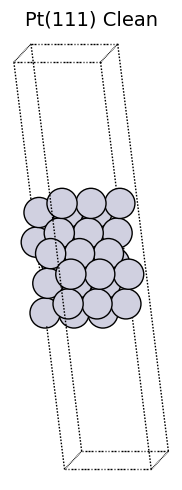

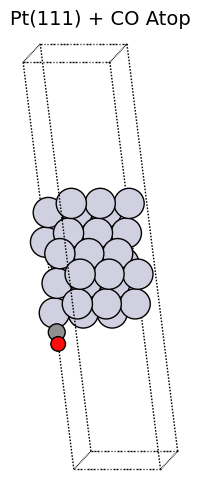

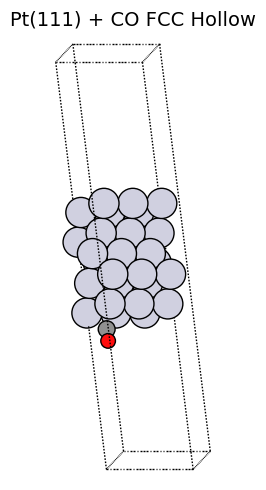

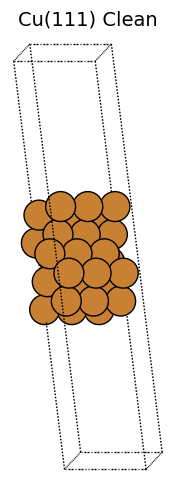

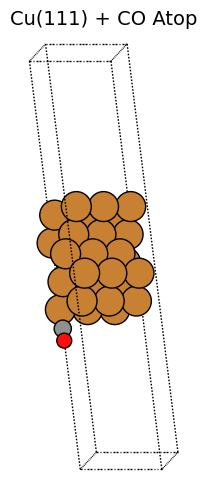

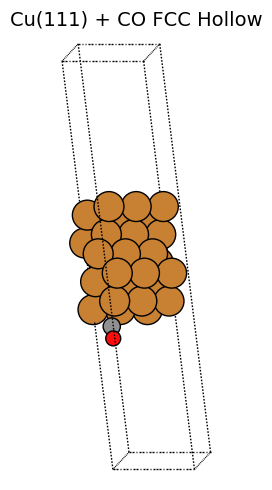

In [33]:
show_structure(atoms_data["pt_clean"], "Pt(111) Clean")
show_structure(atoms_data["pt_atop"], "Pt(111) + CO Atop")
show_structure(atoms_data["pt_fcc"], "Pt(111) + CO FCC Hollow")

show_structure(atoms_data["cu_clean"], "Cu(111) Clean")
show_structure(atoms_data["cu_atop"], "Cu(111) + CO Atop")
show_structure(atoms_data["cu_fcc"], "Cu(111) + CO FCC Hollow")

In [34]:
def make_surface_comparison_figure(atoms_dict, save_path=None, rotation="70x,20y,0z"):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    ordered_items = [
        ("pt_clean", "Pt(111) Clean"),
        ("pt_atop", "Pt(111) Atop"),
        ("pt_fcc", "Pt(111) FCC Hollow"),
        ("cu_clean", "Cu(111) Clean"),
        ("cu_atop", "Cu(111) Atop"),
        ("cu_fcc", "Cu(111) FCC Hollow"),
    ]

    for ax, (key, title) in zip(axes.flatten(), ordered_items):
        plot_atoms(atoms_dict[key], ax, rotation=rotation)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

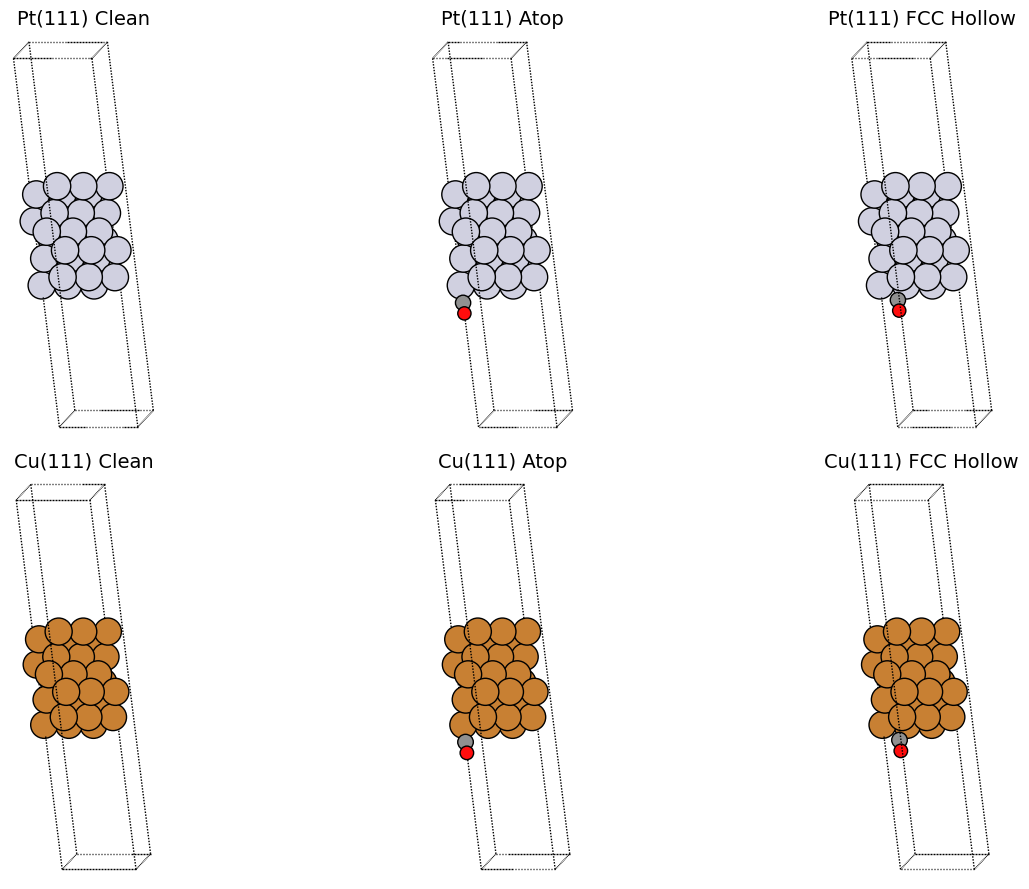

In [35]:
make_surface_comparison_figure(
    atoms_data,
    save_path=fig_directory / "pt_cu_structure_comparison.png"
)

In [36]:
def make_one_surface_figure(clean_atoms, atop_atoms, fcc_atoms, surface_name, save_path=None, rotation="70x,20y,0z"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    entries = [
        (clean_atoms, f"{surface_name} Clean"),
        (atop_atoms, f"{surface_name} Atop"),
        (fcc_atoms, f"{surface_name} FCC Hollow"),
    ]

    for ax, (atoms, title) in zip(axes, entries):
        plot_atoms(atoms, ax, rotation=rotation)
        ax.set_title(title, fontsize=14)
        ax.set_axis_off()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

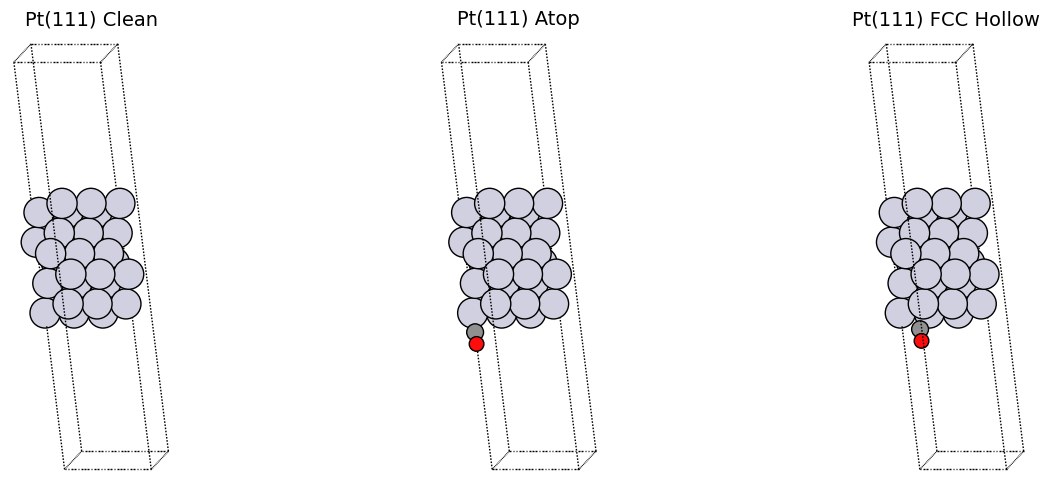

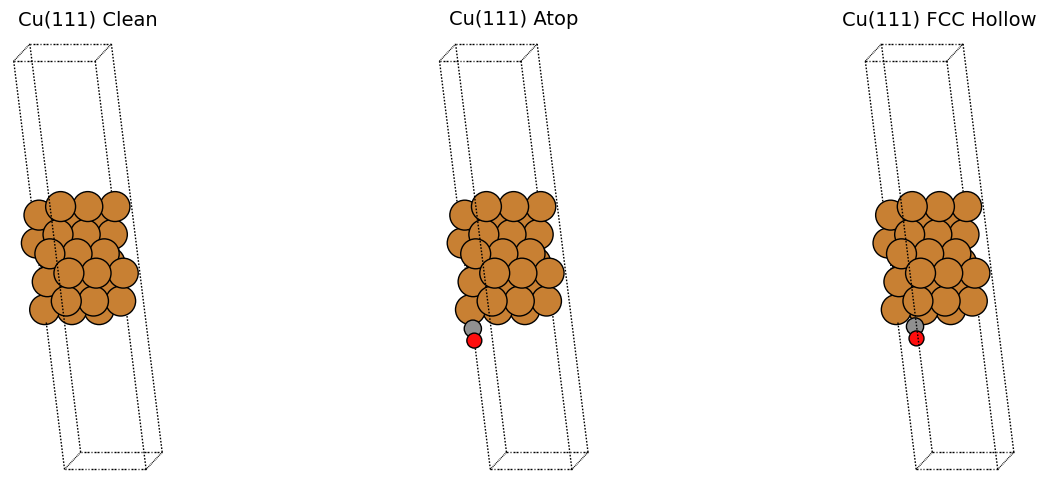

In [37]:
make_one_surface_figure(
    atoms_data["pt_clean"],
    atoms_data["pt_atop"],
    atoms_data["pt_fcc"],
    "Pt(111)",
    save_path=fig_directory / "pt111_sites.png"
)

make_one_surface_figure(
    atoms_data["cu_clean"],
    atoms_data["cu_atop"],
    atoms_data["cu_fcc"],
    "Cu(111)",
    save_path=fig_directory / "cu111_sites.png"
)

In [38]:
energies = {
    "Pt(111)": {
        "Atop": -0.855973,
        "FCC Hollow": -1.144199,
    },
    "Cu(111)": {
        "Atop": -0.163861,
        "FCC Hollow": -0.255953,
    }
}

pt_atop = energies["Pt(111)"]["Atop"]
pt_fcc = energies["Pt(111)"]["FCC Hollow"]
cu_atop = energies["Cu(111)"]["Atop"]
cu_fcc = energies["Cu(111)"]["FCC Hollow"]

print("Pt(111):")
print("  Atop      =", pt_atop, "eV")
print("  FCC Hollow=", pt_fcc, "eV")
print("  ΔE (fcc - atop) =", pt_fcc - pt_atop, "eV")

print("\nCu(111):")
print("  Atop      =", cu_atop, "eV")
print("  FCC Hollow=", cu_fcc, "eV")
print("  ΔE (fcc - atop) =", cu_fcc - cu_atop, "eV")

Pt(111):
  Atop      = -0.855973 eV
  FCC Hollow= -1.144199 eV
  ΔE (fcc - atop) = -0.288226 eV

Cu(111):
  Atop      = -0.163861 eV
  FCC Hollow= -0.255953 eV
  ΔE (fcc - atop) = -0.09209199999999998 eV


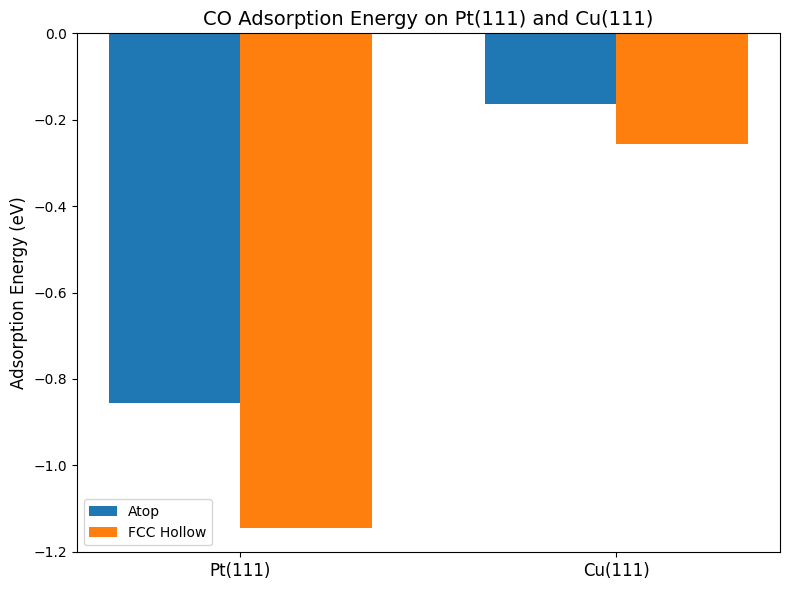

In [39]:
surfaces = ["Pt(111)", "Cu(111)"]
atop_vals = [energies[s]["Atop"] for s in surfaces]
fcc_vals = [energies[s]["FCC Hollow"] for s in surfaces]

x = range(len(surfaces))
width = 0.35

plt.figure(figsize=(8, 6))
plt.bar([i - width/2 for i in x], atop_vals, width=width, label="Atop")
plt.bar([i + width/2 for i in x], fcc_vals, width=width, label="FCC Hollow")

plt.xticks(list(x), surfaces, fontsize=12)
plt.ylabel("Adsorption Energy (eV)", fontsize=12)
plt.title("CO Adsorption Energy on Pt(111) and Cu(111)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(fig_directory / "adsorption_energy_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

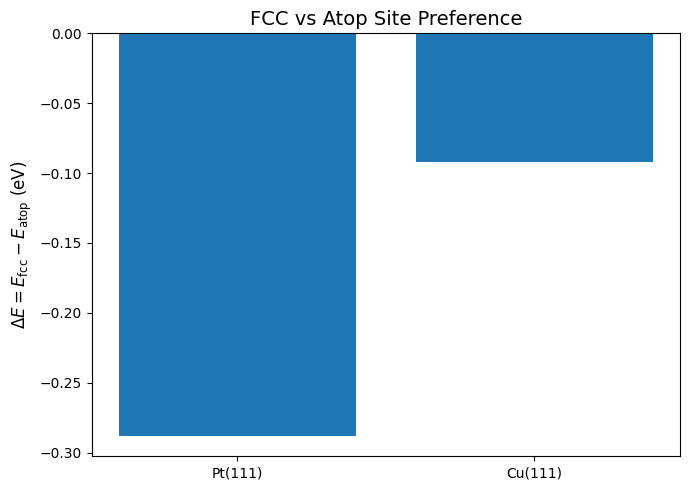

In [40]:
delta_e = {
    "Pt(111)": pt_fcc - pt_atop,
    "Cu(111)": cu_fcc - cu_atop,
}

labels = list(delta_e.keys())
values = list(delta_e.values())

plt.figure(figsize=(7, 5))
plt.bar(labels, values)
plt.ylabel(r"$\Delta E = E_{\mathrm{fcc}} - E_{\mathrm{atop}}$ (eV)", fontsize=12)
plt.title("FCC vs Atop Site Preference", fontsize=14)
plt.tight_layout()
plt.savefig(fig_directory / "site_preference_difference.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
import pandas as pd

summary_df = pd.DataFrame(
    {
        "Surface": ["Pt(111)", "Cu(111)"],
        "Atop Adsorption Energy (eV)": [pt_atop, cu_atop],
        "FCC Adsorption Energy (eV)": [pt_fcc, cu_fcc],
        "ΔE = E_fcc - E_atop (eV)": [pt_fcc - pt_atop, cu_fcc - cu_atop],
    }
)

summary_df

,Surface,Atop Adsorption Energy (eV),FCC Adsorption Energy (eV),ΔE = E_fcc - E_atop (eV)
0,Pt(111),-0.855973,-1.144199,-0.288226
1,Cu(111),-0.163861,-0.255953,-0.092092


In [42]:
summary_df.to_csv(fig_directory / "adsorption_energy_summary.csv", index=False)
print("Saved:", fig_directory / "adsorption_energy_summary.csv")

Saved: figures/adsorption_energy_summary.csv


In [43]:
print("Main takeaways:")
print("1. CO binds more strongly to Pt(111) than to Cu(111).")
print("2. FCC hollow is more stable than atop on both surfaces in these DFT calculations.")
print("3. The Pt(111) site preference difference is much larger than the Cu(111) difference.")

Main takeaways:
1. CO binds more strongly to Pt(111) than to Cu(111).
2. FCC hollow is more stable than atop on both surfaces in these DFT calculations.
3. The Pt(111) site preference difference is much larger than the Cu(111) difference.
